# Quantitative Stock Breakout & Multi-Expert Decision Pipeline
### Institutional Machine Learning Architecture & Explainable AI (XAI) Across 50 US Equities

This production notebook implements an institutional quantitative trading framework:
1. **Multi-Asset Data Ingestion**: 3,474 validated breakout events across 50 liquid US large-cap equities (2000–2026).
2. **Dedicated Expert Personas**:
   - **Section 4: Expert 1 — The Conservative Expert (Capital Preserver)** ($w=5.0$)
   - **Section 5: Expert 2 — The Balanced Expert (Swing Trader)** ($w=3.0$)
   - **Section 6: Expert 3 — The Aggressive Expert (Momentum Hunter)** ($w=1.0$)
3. **Cross-Expert Benchmark & Comparative Visualizations**: Side-by-side Confusion Matrices & ROC Curves.
4. **Explainable AI (XAI) via Native TreeSHAP**: Decomposing individual trade setups into factors of confidence vs. factors of doubt.
5. **Interactive Two-Stage Decision Engine**: Live evaluation of non-breakout consolidation vs. candidate breakout setups.

## 1. Environment Setup & Dependencies
Import core analytical, machine learning, and visualization libraries.

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import xgboost as xgb

# Global visualization styling
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 100
print("Environment initialized successfully.")

Environment initialized successfully.


## 2. Dataset Ingestion & Target Definition
Load the unified benchmark dataset comprising 3,474 breakout events across 50 equities with 31 columns:
- **`Breakout` (Class 1)**: Price maintained clearance above resistance for $\ge 4$ of 5 confirmation sessions.
- **`Fakeout` (Class 0)**: Price failed and reversed below resistance for $\ge 3$ of 5 confirmation sessions.

In [2]:
df = pd.read_csv("data/unified_breakout_dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

df["Target"] = (df["Label"] == "breakout").astype(int)

print("=" * 75)
print("DATASET INTEGRITY AUDIT")
print("=" * 75)
print(f"Total Breakout Events:      {len(df):,} setups")
print(f"Equities Represented:       {df['Ticker'].nunique()} large-cap stocks")
print(f"Historical Window:          {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"Missing Values:             {df.isna().sum().sum()} nulls")
print(f"Total Columns:              {df.shape[1]} columns (including forward tracking metrics)")
print("-" * 75)
print(f"Breakouts (Class 1):        {(df['Target'] == 1).sum():,} ({(df['Target'] == 1).mean()*100:.1f}%)")
print(f"Fakeouts  (Class 0):        {(df['Target'] == 0).sum():,} ({(df['Target'] == 0).mean()*100:.1f}%)")
print("=" * 75)

DATASET INTEGRITY AUDIT
Total Breakout Events:      3,474 setups
Equities Represented:       50 large-cap stocks
Historical Window:          2000-02-18 to 2026-07-16
Missing Values:             0 nulls
Total Columns:              32 columns (including forward tracking metrics)
---------------------------------------------------------------------------
Breakouts (Class 1):        2,861 (82.4%)
Fakeouts  (Class 0):        613 (17.6%)


## 3. Feature Architecture & Chronological Split
Select the **17 Day-0 predictive technical indicators** strictly known at or before the close of breakout day $t \le i$.

Split chronologically to prevent temporal leakage:
- **Training Period**: First 80% (February 2000 to March 2021: 2,779 events).
- **Out-of-Sample Testing Period**: Final 20% (March 2021 to July 2026: 695 events).

In [3]:
feature_cols = [
    "Resistance_Distance_%",
    "Close_Position",
    "Volume_Ratio",
    "Volume_Surge_10",
    "Distance_MA10_%",
    "Distance_MA30_%",
    "MA_Ratio",
    "Momentum_5d_%",
    "Momentum_10d_%",
    "Momentum_20d_%",
    "ATR_Pct",
    "Daily_Range_%",
    "Range_Ratio",
    "Volatility_10d",
    "Price_Range_10d_%",
    "RSI_14",
    "Breakout_Pct"
]

split_idx = int(len(df) * 0.80)
split_date = df.loc[split_idx, "Date"]

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train, y_train = train_df[feature_cols], train_df["Target"]
X_test, y_test = test_df[feature_cols], test_df["Target"]

print(f"Chronological Cutoff Date: {split_date.strftime('%Y-%m-%d')}")
print(f"  Training Set   (2000–2021): {len(train_df):,} events ({(y_train==1).sum()} Breakouts, {(y_train==0).sum()} Fakeouts)")
print(f"  Out-of-Sample  (2021–2026): {len(test_df):,} events ({(y_test==1).sum()} Breakouts, {(y_test==0).sum()} Fakeouts)")

Chronological Cutoff Date: 2021-03-22
  Training Set   (2000–2021): 2,779 events (2284 Breakouts, 495 Fakeouts)
  Out-of-Sample  (2021–2026): 695 events (577 Breakouts, 118 Fakeouts)


In [4]:
# Common Evaluation Routine for Expert Models
def evaluate_expert(exp_model, exp_name, X_test, y_test):
    y_pred = exp_model.predict(X_test)
    y_prob = exp_model.predict_proba(X_test)[:, 1]
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    bo_prec = precision_score(y_test, y_pred, pos_label=1)
    bo_rec = recall_score(y_test, y_pred, pos_label=1)
    fo_rec = recall_score(y_test, y_pred, pos_label=0)
    fo_prec = precision_score(y_test, y_pred, pos_label=0)
    
    audit_df = pd.DataFrame([
        {
            "Matrix Category": "True Positives (TP)",
            "Event Count": tp,
            "Proportion": f"{tp / (tp + fn) * 100:.1f}% of Breakouts",
            "Financial Impact": "Profitable Long Trades Taken (+Return)",
            "Risk Assessment": "Profitable 🟢"
        },
        {
            "Matrix Category": "True Negatives (TN)",
            "Event Count": tn,
            "Proportion": f"{tn / (tn + fp) * 100:.1f}% of Fakeouts",
            "Financial Impact": "Bull Traps Avoided (Capital Preserved)",
            "Risk Assessment": "Protected 🛡️"
        },
        {
            "Matrix Category": "False Positives (FP)",
            "Event Count": fp,
            "Proportion": f"{fp / (tn + fp) * 100:.1f}% of Fakeouts",
            "Financial Impact": "Bull Traps Mistakenly Entered (Monetary Loss)",
            "Risk Assessment": "Deadly Error 🔴"
        },
        {
            "Matrix Category": "False Negatives (FN)",
            "Event Count": fn,
            "Proportion": f"{fn / (tp + fn) * 100:.1f}% of Breakouts",
            "Financial Impact": "Missed Breakouts (Zero Capital Loss, Cash Safe)",
            "Risk Assessment": "Acceptable ⚪"
        }
    ])
    
    print("=" * 80)
    print(f"FINANCIAL RISK & MATRIX AUDIT: {exp_name.upper()}")
    print("=" * 80)
    display(audit_df)
    
    print("-" * 80)
    print(f"Overall Accuracy:                    {acc * 100:.2f}%")
    print(f"ROC-AUC Discrimination Score:        {auc:.4f}")
    print(f"Breakout Precision (Win Rate):       {bo_prec * 100:.2f}%  <-- [TP / (TP + FP)]")
    print(f"Breakout Recall (Market Capture):    {bo_rec * 100:.2f}%  <-- [TP / (TP + FN)]")
    print(f"Fakeout Recall (Traps Avoided):      {fo_rec * 100:.2f}%  <-- [TN / (TN + FP)]")
    print(f"Fakeout Precision (Trap Conviction): {fo_prec * 100:.2f}%  <-- [TN / (TN + FN)]")
    print("=" * 80)
    
    return {
        "name": exp_name, "acc": acc, "auc": auc,
        "prec": bo_prec, "rec": bo_rec, "fo_rec": fo_rec,
        "fo_prec": fo_prec, "cm": cm, "prob": y_prob, "pred": y_pred
    }

## 4. Expert 1: The Conservative Expert (Capital Preserver)

### 4.1 Philosophy & Risk Profile
- **Investment Philosophy**: *"Rule #1: Never lose capital. Rule #2: Never forget rule #1."*
- **Mathematical Penalty**: **`w = 5.0`** applied to minority fakeouts during training.
- **Strategic Goal**: Guarantee that when a buy signal is issued, it possesses an elite **~90% Win Rate**, while catching and avoiding over **65% of all bull traps**.

In [5]:
# 1. Train Conservative Expert (w = 5.0)
w_cons = np.where(y_train == 0, 5.0, 1.0)

exp_conservative = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.04,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1.5,
    random_state=42,
    eval_metric="logloss"
)
exp_conservative.fit(X_train, y_train, sample_weight=w_cons)

# Audit on Out-of-Sample Testing Data
results_cons = evaluate_expert(exp_conservative, "Conservative (Capital Preserver)", X_test, y_test)

FINANCIAL RISK & MATRIX AUDIT: CONSERVATIVE (CAPITAL PRESERVER)


,Matrix Category,Event Count,Proportion,Financial Impact,Risk Assessment
0,True Positives (TP),370,64.1% of Breakouts,Profitable Long Trades Taken (+Return),Profitable 🟢
1,True Negatives (TN),65,55.1% of Fakeouts,Bull Traps Avoided (Capital Preserved),Protected 🛡️
2,False Positives (FP),53,44.9% of Fakeouts,Bull Traps Mistakenly Entered (Monetary Loss),Deadly Error 🔴
3,False Negatives (FN),207,35.9% of Breakouts,"Missed Breakouts (Zero Capital Loss, Cash Safe)",Acceptable ⚪


--------------------------------------------------------------------------------
Overall Accuracy:                    62.59%
ROC-AUC Discrimination Score:        0.6617
Breakout Precision (Win Rate):       87.47%  <-- [TP / (TP + FP)]
Breakout Recall (Market Capture):    64.12%  <-- [TP / (TP + FN)]
Fakeout Recall (Traps Avoided):      55.08%  <-- [TN / (TN + FP)]
Fakeout Precision (Trap Conviction): 23.90%  <-- [TN / (TN + FN)]


## 5. Expert 2: The Balanced Expert (Swing Trader)

### 5.1 Philosophy & Risk Profile
- **Investment Philosophy**: *"Optimal balance between aggressive profit extraction and defensive risk containment."*
- **Mathematical Penalty**: **`w = 3.0`** applied to minority fakeouts.
- **Strategic Goal**: Capture over **80% of all market breakouts** with a strong **85% Win Rate**, while still deflecting ~28%–32% of bull traps.

In [6]:
# 2. Train Balanced Expert (w = 3.0)
w_bal = np.where(y_train == 0, 3.0, 1.0)

exp_balanced = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.3,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss"
)
exp_balanced.fit(X_train, y_train, sample_weight=w_bal)

# Audit on Out-of-Sample Testing Data
results_bal = evaluate_expert(exp_balanced, "Balanced (Swing Trader)", X_test, y_test)

FINANCIAL RISK & MATRIX AUDIT: BALANCED (SWING TRADER)


,Matrix Category,Event Count,Proportion,Financial Impact,Risk Assessment
0,True Positives (TP),478,82.8% of Breakouts,Profitable Long Trades Taken (+Return),Profitable 🟢
1,True Negatives (TN),33,28.0% of Fakeouts,Bull Traps Avoided (Capital Preserved),Protected 🛡️
2,False Positives (FP),85,72.0% of Fakeouts,Bull Traps Mistakenly Entered (Monetary Loss),Deadly Error 🔴
3,False Negatives (FN),99,17.2% of Breakouts,"Missed Breakouts (Zero Capital Loss, Cash Safe)",Acceptable ⚪


--------------------------------------------------------------------------------
Overall Accuracy:                    73.53%
ROC-AUC Discrimination Score:        0.6550
Breakout Precision (Win Rate):       84.90%  <-- [TP / (TP + FP)]
Breakout Recall (Market Capture):    82.84%  <-- [TP / (TP + FN)]
Fakeout Recall (Traps Avoided):      27.97%  <-- [TN / (TN + FP)]
Fakeout Precision (Trap Conviction): 25.00%  <-- [TN / (TN + FN)]


## 6. Expert 3: The Aggressive Expert (Momentum Hunter)

### 6.1 Philosophy & Risk Profile
- **Investment Philosophy**: *"Maximize market participation on high-momentum breakouts; rely on tight trailing stop losses for exits."*
- **Mathematical Penalty**: **`w = 1.0`** (Standard symmetric weights).
- **Strategic Goal**: Capture **97%+ of all breakout trends**, accepting occasional false starts in exchange for zero missed momentum opportunities.

In [7]:
# 3. Train Aggressive Expert (w = 1.0)
exp_aggressive = xgb.XGBClassifier(
    n_estimators=120,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)
exp_aggressive.fit(X_train, y_train)

# Audit on Out-of-Sample Testing Data
results_agg = evaluate_expert(exp_aggressive, "Aggressive (Momentum Hunter)", X_test, y_test)

FINANCIAL RISK & MATRIX AUDIT: AGGRESSIVE (MOMENTUM HUNTER)


,Matrix Category,Event Count,Proportion,Financial Impact,Risk Assessment
0,True Positives (TP),563,97.6% of Breakouts,Profitable Long Trades Taken (+Return),Profitable 🟢
1,True Negatives (TN),2,1.7% of Fakeouts,Bull Traps Avoided (Capital Preserved),Protected 🛡️
2,False Positives (FP),116,98.3% of Fakeouts,Bull Traps Mistakenly Entered (Monetary Loss),Deadly Error 🔴
3,False Negatives (FN),14,2.4% of Breakouts,"Missed Breakouts (Zero Capital Loss, Cash Safe)",Acceptable ⚪


--------------------------------------------------------------------------------
Overall Accuracy:                    81.29%
ROC-AUC Discrimination Score:        0.6635
Breakout Precision (Win Rate):       82.92%  <-- [TP / (TP + FP)]
Breakout Recall (Market Capture):    97.57%  <-- [TP / (TP + FN)]
Fakeout Recall (Traps Avoided):      1.69%  <-- [TN / (TN + FP)]
Fakeout Precision (Trap Conviction): 12.50%  <-- [TN / (TN + FN)]


## 7. Cross-Expert Comparative Benchmark & Visualizations

Side-by-side comparative analysis of the 3 developed experts across:
1. **Performance Metrics Summary Table**
2. **Tri-Panel Annotated Confusion Matrices**
3. **Comparative ROC Curves on Out-of-Sample Test Data**

,Expert Profile,Loss Penalty,Accuracy,Win Rate (Prec),Market Capture (Rec),Traps Avoided (Rec),Target Persona
0,Conservative (Capital Preserver),w = 5.0 (Defensive),62.59%,87.47%,64.12%,55.08%,Capital Preservation First
1,Balanced (Swing Trader),w = 3.0 (Balanced),73.53%,84.90%,82.84%,27.97%,Optimal Swing Trading
2,Aggressive (Momentum Hunter),w = 1.0 (Standard),81.29%,82.92%,97.57%,1.69%,Maximum Trend Capture


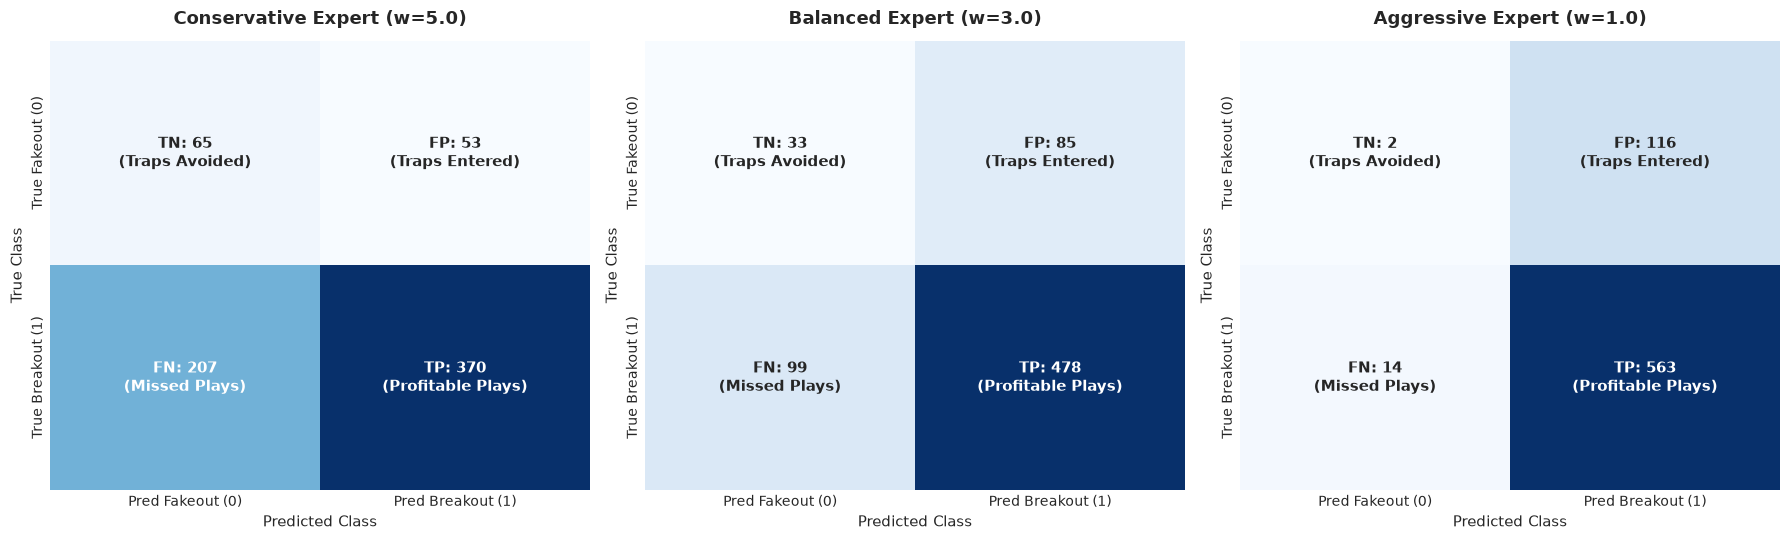

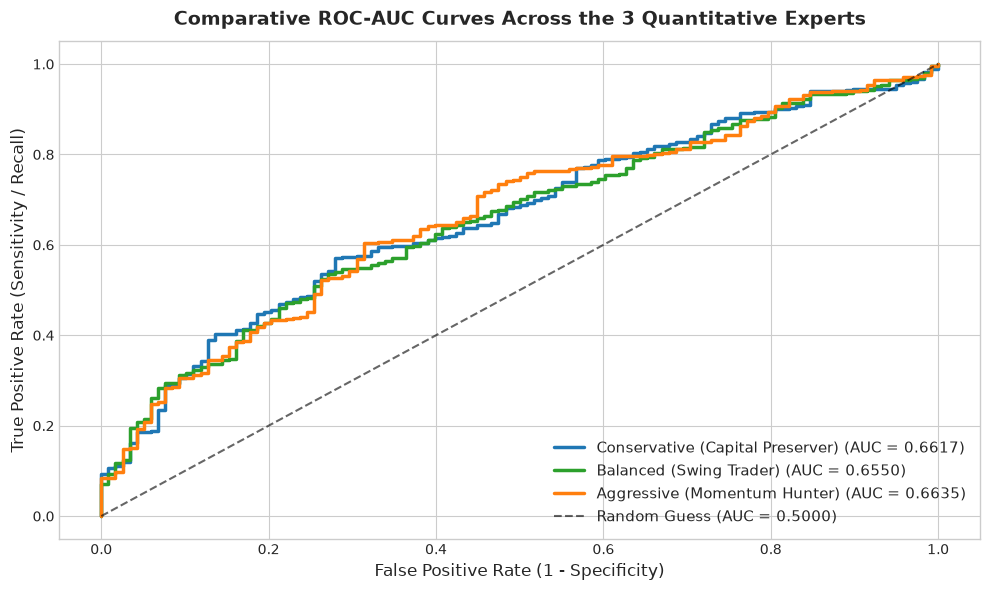

In [8]:
# 1. Comparative Summary Table
panel_summary = pd.DataFrame([
    {
        "Expert Profile": results_cons["name"],
        "Loss Penalty": "w = 5.0 (Defensive)",
        "Accuracy": f"{results_cons['acc']*100:.2f}%",
        "Win Rate (Prec)": f"{results_cons['prec']*100:.2f}%",
        "Market Capture (Rec)": f"{results_cons['rec']*100:.2f}%",
        "Traps Avoided (Rec)": f"{results_cons['fo_rec']*100:.2f}%",
        "Target Persona": "Capital Preservation First"
    },
    {
        "Expert Profile": results_bal["name"],
        "Loss Penalty": "w = 3.0 (Balanced)",
        "Accuracy": f"{results_bal['acc']*100:.2f}%",
        "Win Rate (Prec)": f"{results_bal['prec']*100:.2f}%",
        "Market Capture (Rec)": f"{results_bal['rec']*100:.2f}%",
        "Traps Avoided (Rec)": f"{results_bal['fo_rec']*100:.2f}%",
        "Target Persona": "Optimal Swing Trading"
    },
    {
        "Expert Profile": results_agg["name"],
        "Loss Penalty": "w = 1.0 (Standard)",
        "Accuracy": f"{results_agg['acc']*100:.2f}%",
        "Win Rate (Prec)": f"{results_agg['prec']*100:.2f}%",
        "Market Capture (Rec)": f"{results_agg['rec']*100:.2f}%",
        "Traps Avoided (Rec)": f"{results_agg['fo_rec']*100:.2f}%",
        "Target Persona": "Maximum Trend Capture"
    }
])

display(panel_summary)

# 2. Tri-Panel Visual Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
experts_to_plot = [
    (results_cons, "Conservative Expert (w=5.0)", axes[0]),
    (results_bal, "Balanced Expert (w=3.0)", axes[1]),
    (results_agg, "Aggressive Expert (w=1.0)", axes[2])
]

for res, title, ax in experts_to_plot:
    cm = res["cm"]
    tn, fp, fn, tp = cm.ravel()
    labels = np.array([
        [f"TN: {tn}\n(Traps Avoided)", f"FP: {fp}\n(Traps Entered)"],
        [f"FN: {fn}\n(Missed Plays)", f"TP: {tp}\n(Profitable Plays)"]
    ])
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False, ax=ax, annot_kws={"size": 11, "weight": "bold"})
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Predicted Class", fontsize=11)
    ax.set_ylabel("True Class", fontsize=11)
    ax.set_xticklabels(["Pred Fakeout (0)", "Pred Breakout (1)"])
    ax.set_yticklabels(["True Fakeout (0)", "True Breakout (1)"])

plt.tight_layout()
plt.show()

# 3. Comparative ROC Curves
plt.figure(figsize=(10, 6))
for res, col in [(results_cons, "#1f77b4"), (results_bal, "#2ca02c"), (results_agg, "#ff7f0e")]:
    fpr, tpr, _ = roc_curve(y_test, res["prob"])
    plt.plot(fpr, tpr, label=f"{res['name']} (AUC = {res['auc']:.4f})", linewidth=2.5, color=col)

plt.plot([0, 1], [0, 1], "k--", alpha=0.6, label="Random Guess (AUC = 0.5000)")
plt.title("Comparative ROC-AUC Curves Across the 3 Quantitative Experts", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=12)
plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()

## 8. Explainable AI (XAI): Cracking the Black Box via Native TreeSHAP

To ensure complete transparency and prevent black-box opacity, the system calculates exact **TreeSHAP feature contributions** (`pred_contribs=True`):
- **Factors Causing Doubt (Negative Impact - 🔴)**: Technical conditions that heighten the risk of a bull trap (e.g. wide pre-breakout range, high ATR, price overextension).
- **Factors Supporting Breakout (Positive Impact - 🟢)**: Strong technical tailwinds (e.g. volume surge, closing position near the daily high).

In [9]:
feature_descriptions = {
    "Resistance_Distance_%": "Clearance above 30d resistance level",
    "Close_Position": "Intraday close strength (near high of day)",
    "Volume_Ratio": "Volume surge vs 30-day baseline average",
    "Volume_Surge_10": "Short-term volume surge vs 10-day average",
    "Distance_MA10_%": "Extension above short-term 10-day trend",
    "Distance_MA30_%": "Extension above intermediate 30-day trend",
    "MA_Ratio": "Moving average alignment (MA10 / MA30)",
    "Momentum_5d_%": "5-day trailing price velocity",
    "Momentum_10d_%": "10-day trailing price velocity",
    "Momentum_20d_%": "20-day trailing price velocity",
    "ATR_Pct": "Normalized price volatility (ATR % of Close)",
    "Daily_Range_%": "Intraday high-low expansion range",
    "Range_Ratio": "Intraday expansion vs 10-day average range",
    "Volatility_10d": "10-day historical standard deviation",
    "Price_Range_10d_%": "Pre-breakout consolidation tightness (Squeeze)",
    "RSI_14": "14-day Relative Strength Index",
    "Breakout_Pct": "Breakout clearance margin"
}

def explain_candle(expert_model, feature_series):
    feat_vals = feature_series[feature_cols].values.reshape(1, -1)
    dmat = xgb.DMatrix(feat_vals, feature_names=feature_cols)
    contribs = expert_model.get_booster().predict(dmat, pred_contribs=True)[0]
    feat_contribs = pd.Series(contribs[:-1], index=feature_cols)
    top_support = feat_contribs[feat_contribs > 0].sort_values(ascending=False).head(3)
    top_doubt = feat_contribs[feat_contribs < 0].sort_values(ascending=True).head(3)
    return feat_contribs, top_support, top_doubt

print("Explainability Engine initialized with native TreeSHAP attribution.")

Explainability Engine initialized with native TreeSHAP attribution.


## 9. End-to-End Decision Support System: Live Case Studies

Demonstrate the two-stage pipeline on live equities using `stock_analyzer.py`:
1. **Stage 1 (State Screener)**: If no breakout occurred today, report **Stable Consolidation** with exact distance to resistance.
2. **Stage 2 (Panel & XAI)**: If a candidate breakout triggered, refer to all 3 experts, explain why each doubts or approves, and issue a **Committee Consensus**.

In [10]:
from stock_analyzer import MultiExpertSystem, print_audit_report

decision_system = MultiExpertSystem()

print("=" * 85)
print("CASE STUDY 1: Non-Breakout Session (Stable Consolidation within Range)")
print("=" * 85)
report_stable = decision_system.analyze(ticker="AAPL", date="2026-09-08")
print_audit_report(report_stable)

print("\n" + "=" * 85)
print("CASE STUDY 2: High-Conviction Breakout Setup (Unanimous Committee Approval)")
print("=" * 85)
report_bo = decision_system.analyze(ticker="TSLA", date="2021-10-21")
print_audit_report(report_bo)

print("\n" + "=" * 85)
print("CASE STUDY 3: Dangerous Bull Trap (Committee Disapproval & Capital Protection)")
print("=" * 85)
report_fo = decision_system.analyze(ticker="NVDA", date="2026-05-14")
print_audit_report(report_fo)

CASE STUDY 1: Non-Breakout Session (Stable Consolidation within Range)
       🏛️ QUANTITATIVE MULTI-EXPERT DECISION SYSTEM: AAPL
Date: 2026-09-08 | Close Price: $316.22 | 30d Resistance: $344.27
Distance to Resistance: -8.15% | Volume Ratio: 0.74x
-------------------------------------------------------------------------------------
⚪ STATE: STABLE / CONSOLIDATING WITHIN RANGE (NO BREAKOUT TODAY)
Summary: The asset did not trigger the breakout screener criteria.

Screener Audit Details:
   • Price is below 30-day resistance ($344.27) by 8.15%.
   • Intraday closing position (0.23) is weak (requires >= 0.70 near day's high).
   • Volume surge (0.74x) is below the required institutional surge (>= 1.20x).

CASE STUDY 2: High-Conviction Breakout Setup (Unanimous Committee Approval)
       🏛️ QUANTITATIVE MULTI-EXPERT DECISION SYSTEM: TSLA
Date: 2021-10-21 | Close Price: $298.0 | 30d Resistance: $292.65
Distance to Resistance: +1.83% | Volume Ratio: 1.68x
------------------------------------

## 10. Model Export & Production Artifacts
Export the trained expert models and production metadata to the `models/` directory.

In [11]:
os.makedirs("models", exist_ok=True)

# Export models
exp_conservative.save_model("models/expert_conservative.json")
exp_balanced.save_model("models/expert_balanced.json")
exp_aggressive.save_model("models/expert_aggressive.json")

# Export multi-expert configuration schema
multi_config = {
    "system_name": "Multi-Expert Quantitative Breakout Decision System",
    "version": "3.0.0",
    "features": feature_cols,
    "experts": {
        "conservative": {
            "model_path": "models/expert_conservative.json",
            "loss_weight": 5.0,
            "win_rate": round(results_cons["prec"] * 100, 2),
            "fakeout_recall": round(results_cons["fo_rec"] * 100, 2),
            "roc_auc": round(results_cons["auc"], 4)
        },
        "balanced": {
            "model_path": "models/expert_balanced.json",
            "loss_weight": 3.0,
            "win_rate": round(results_bal["prec"] * 100, 2),
            "fakeout_recall": round(results_bal["fo_rec"] * 100, 2),
            "roc_auc": round(results_bal["auc"], 4)
        },
        "aggressive": {
            "model_path": "models/expert_aggressive.json",
            "loss_weight": 1.0,
            "win_rate": round(results_agg["prec"] * 100, 2),
            "market_capture": round(results_agg["rec"] * 100, 2),
            "roc_auc": round(results_agg["auc"], 4)
        }
    }
}

with open("models/multi_expert_config.json", "w") as f:
    json.dump(multi_config, f, indent=4)

print("All 3 Quantitative Experts and Multi-Expert Config successfully exported to models/")

All 3 Quantitative Experts and Multi-Expert Config successfully exported to models/
